In [12]:
import pandas as pd
import os 
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.tree import plot_tree

In [4]:
df = pd.read_csv('../banco_fenotipos_conformal.csv') # Load the phenotypic data
df = df.drop(columns=['id','samplefilename', 'CP1','CP2','CP3','CP4','CP5','CP6']) # remove the id from the table
colunas_categoricas = ['fumo', 'raca_cor', 'conjugal3', 'trabalho2', 'bebem2']
df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True, dtype=int) # Turns the categorical columns into 0 and 1

In [ ]:
def extrair_importancias_grafo(df, alvos, num_trees=500, iteracoes=50, fracao_amostra=0.5):
    
    # Create the empty array
    matriz_estabilidade = pd.DataFrame(
            index=alvos, columns=df.columns, dtype=np.float64
        ).fillna(0.0)    
    # Iterate for all variables in target variables
    for target in alvos:
        nopcoes = df[target].nunique()
        if nopcoes > 5:
            print(f'{target} é regressor')
        else:
            print(f'{target} é classifier')
        df_alvo = df.dropna(subset=[target])
        
        # Iterate for the stability selection
        for i in range(iteracoes):
            df_sub = df_alvo.sample(frac=fracao_amostra, random_state=i)
            
            X = df_sub.drop(columns=[target])
            y = df_sub[target]
            
            if nopcoes > 5:
                modelorf = RandomForestRegressor(n_estimators=num_trees, n_jobs=-1, max_features=0.3, max_depth=8)
            else:
                modelorf = RandomForestClassifier(n_estimators=num_trees, n_jobs=-1, max_features=0.3, max_depth=8)
                
            modelorf.fit(X, y)
            importancias = modelorf.feature_importances_
            
            
            matriz_estabilidade.loc[target, X.columns] += importancias
            
        # Gets the mean of the importance
        matriz_estabilidade.loc[target] = matriz_estabilidade.loc[target] / iteracoes
        
    return matriz_estabilidade

In [48]:
%%time
matriz_final = extrair_importancias_grafo(df, df.columns, 300, 5)

hb_g_dl é regressor
glicose_mg_dl é regressor
sexo é classifier
idade é regressor
faixa_etaria é classifier
imc é regressor
imc_cat4_aferido é classifier
imc_cat_aferido é classifier
ep é classifier
obesidade é classifier
ccm é regressor
obes_central é classifier
cc_estat é regressor
cc_estat_cat é classifier
medDM_bioq é classifier
diabetes2 é classifier
HOMA_IR é regressor
HOMA_cat é classifier
pas_final é regressor
pad_final é regressor
medHAS_bioq é classifier
has2 é classifier
col_nao_hdlc_mg_dl é regressor
colnaohdl_cat é classifier
fumo_fumante é classifier
fumo_nunca é classifier
fumo_não respondeu é classifier
raca_cor_branca é classifier
raca_cor_indígena é classifier
raca_cor_não respondeu é classifier
raca_cor_outras é classifier
raca_cor_parda é classifier
raca_cor_preta é classifier
conjugal3_casado/un. estavel é classifier
conjugal3_separado/desq/divorc é classifier
conjugal3_solteiro é classifier
conjugal3_viuvo é classifier
trabalho2_estudante é classifier
trabalho2_nÃ

In [50]:
matriz_final

,hb_g_dl,glicose_mg_dl,sexo,idade,faixa_etaria,imc,imc_cat4_aferido,imc_cat_aferido,ep,obesidade,...,conjugal3_casado/un. estavel,conjugal3_separado/desq/divorc,conjugal3_solteiro,conjugal3_viuvo,trabalho2_estudante,trabalho2_nÃ£o trabalha,trabalho2_trabalha,bebem2_NS/NR,bebem2_atÃ© 3x semana,bebem2_nÃ£o bebe
hb_g_dl,0.000000,0.070285,0.046912,0.076246,0.006839,0.070884,0.015215,0.010933,0.005350,0.004058,...,0.007253,0.008240,0.004127,0.013393,0.001273,0.008141,0.013898,0.002268,0.009214,0.008001
glicose_mg_dl,0.050648,0.000000,0.007089,0.052560,0.023876,0.063949,0.018562,0.004637,0.002672,0.002369,...,0.006290,0.001842,0.005585,0.005173,0.000635,0.004881,0.004599,0.000317,0.003187,0.003887
sexo,0.195685,0.059202,0.000000,0.039556,0.005100,0.048314,0.011255,0.006141,0.003039,0.002968,...,0.016696,0.003130,0.003441,0.013441,0.002370,0.007131,0.009392,0.001709,0.005871,0.011731
idade,0.007418,0.011255,0.000873,0.000000,0.283586,0.175479,0.130092,0.001708,0.001298,0.000464,...,0.002121,0.001383,0.055868,0.004377,0.031566,0.022581,0.015223,0.000950,0.000945,0.000993
faixa_etaria,0.003298,0.006564,0.000369,0.441227,0.000000,0.126511,0.135357,0.003327,0.002836,0.000227,...,0.003785,0.000320,0.028079,0.002886,0.029764,0.015559,0.014116,0.000202,0.000357,0.000434
imc,0.010374,0.007956,0.001811,0.014231,0.003160,0.000000,0.171609,0.179510,0.122500,0.133692,...,0.001554,0.002658,0.000859,0.001036,0.000034,0.001501,0.001383,0.000943,0.001619,0.001243
imc_cat4_aferido,0.007310,0.007318,0.001137,0.042992,0.022216,0.219638,0.000000,0.243271,0.172947,0.119001,...,0.001103,0.001908,0.000489,0.000842,0.000051,0.003477,0.004744,0.000795,0.001078,0.001199
imc_cat_aferido,0.003340,0.002752,0.000417,0.010951,0.005262,0.115765,0.180555,0.000000,0.334508,0.210061,...,0.000153,0.000071,0.000577,0.000265,0.001270,0.000296,0.000376,0.000035,0.000258,0.000362
ep,0.001937,0.002209,0.000234,0.008894,0.005097,0.108501,0.216055,0.464458,0.000000,0.052526,...,0.000113,0.000009,0.000551,0.000204,0.001050,0.000242,0.000199,0.000027,0.000095,0.000049
obesidade,0.002746,0.003359,0.000509,0.007025,0.001407,0.169054,0.190075,0.427866,0.029246,0.000000,...,0.000219,0.000188,0.000484,0.000028,0.001773,0.000034,0.000102,0.000006,0.000400,0.000126


In [55]:
matriz_numpy = matriz_final.to_numpy()

matriz_min = np.minimum(matriz_numpy,matriz_numpy.T)

matriz_inf = np.tril(matriz_min, k=-1)

matriz = pd.DataFrame(
    matriz_min, index=matriz_final.index, columns=matriz_final.columns
)

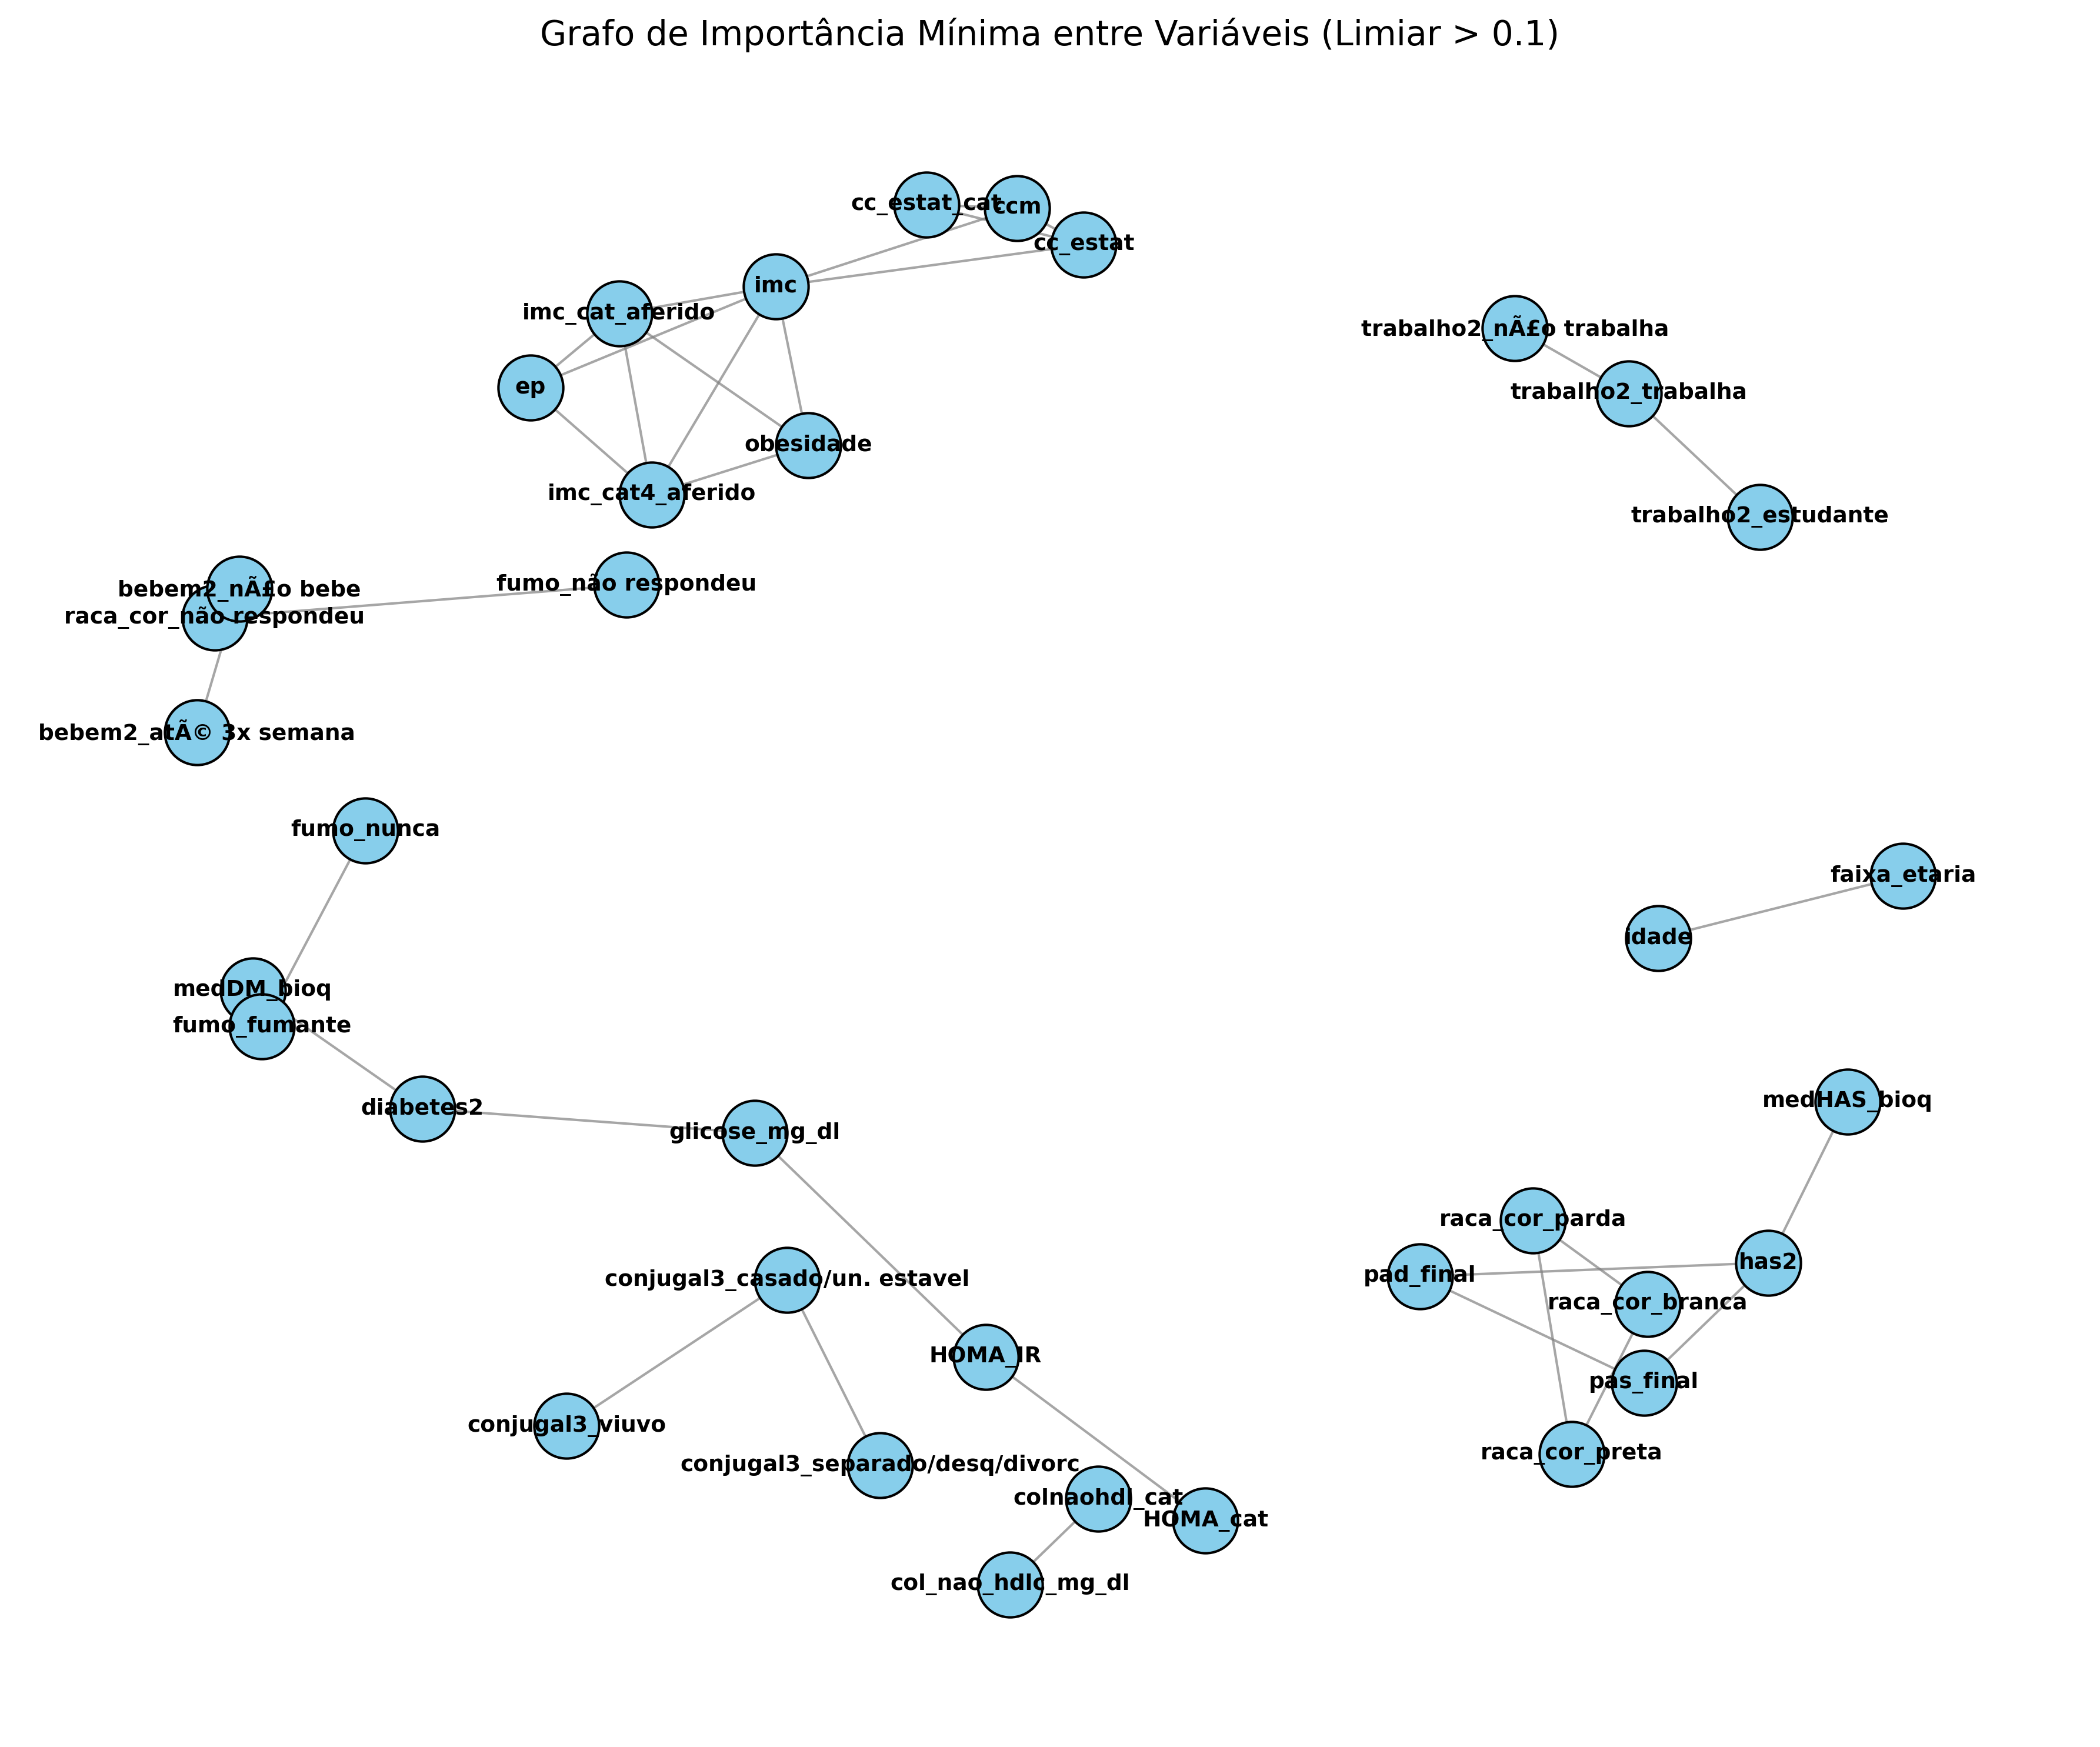

In [66]:
IMPORT_MIN = 0.1
G = nx.from_pandas_adjacency(matriz, create_using=nx.Graph)

arestas_para_remover = [
    (u, v)
    for u, v, d in G.edges(data=True)
    if d["weight"] <= IMPORT_MIN
]
G.remove_edges_from(arestas_para_remover)

# 3. Remove nós que ficaram totalmente isolados (opcional, para limpar o grafo)
nos_isolados = list(nx.isolates(G))
G.remove_nodes_from(nos_isolados)

# --- ESTILIZAÇÃO DO GRAFO ---
plt.figure(figsize=(12, 10), dpi=300)

# Define o layout das bolinhas (Fruchterman-Reingold força as conexões próximas)
pos = nx.spring_layout(G, k=0.8, weight='weight', iterations=150)

# Extrai os pesos para usar na espessura das linhas
pesos = [G[u][v]["weight"] * 100 for u, v in G.edges()]  # Multiplicado por 100 para dar espessura visível

# Desenha os Nós (Bolinhas)
nx.draw_networkx_nodes(
    G, pos, node_size=700, node_color="skyblue", edgecolors="black"
)

# Desenha as Arestas (Linhas) com espessura proporcional à importância
nx.draw_networkx_edges(
    G, pos, width=1, edge_color="gray", alpha=0.7, arrows=True
)

# Desenha os Nomes das Variáveis
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title(
    f"Grafo de Importância Mínima entre Variáveis (Limiar > {IMPORT_MIN})",
    fontsize=14,
)
plt.axis("off")
plt.tight_layout()
plt.show()